<a href="https://colab.research.google.com/github/nati-bel23/python-segmentation-pipeline/blob/main/Rust_Segmentation_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rust Leaf Segmentation - Color-Based (Fixed)
## Properly segments rust spots on leaves using HSV color analysis

## Step 1: Install and Import

In [ ]:
!pip install opencv-python-headless pillow pandas -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from google.colab import drive

print('Setup complete!')

Setup complete!


## Step 2: Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3: Setup Paths

In [ ]:
RUST_IMAGES_PATH   = '/content/drive/MyDrive/Dataset/Rust'
NORUST_IMAGES_PATH = '/content/drive/MyDrive/Dataset/NoRust'
OUTPUT_PATH        = '/content/drive/MyDrive/Segmented_Dataset'

os.makedirs(f'{OUTPUT_PATH}/images',        exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/masks',         exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/labels',        exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/visualization', exist_ok=True)

print('Directories ready!')

Directories ready!


## Step 4: Tune Rust Color Ranges on a Sample Image
### Run this cell first to calibrate the color ranges for YOUR dataset

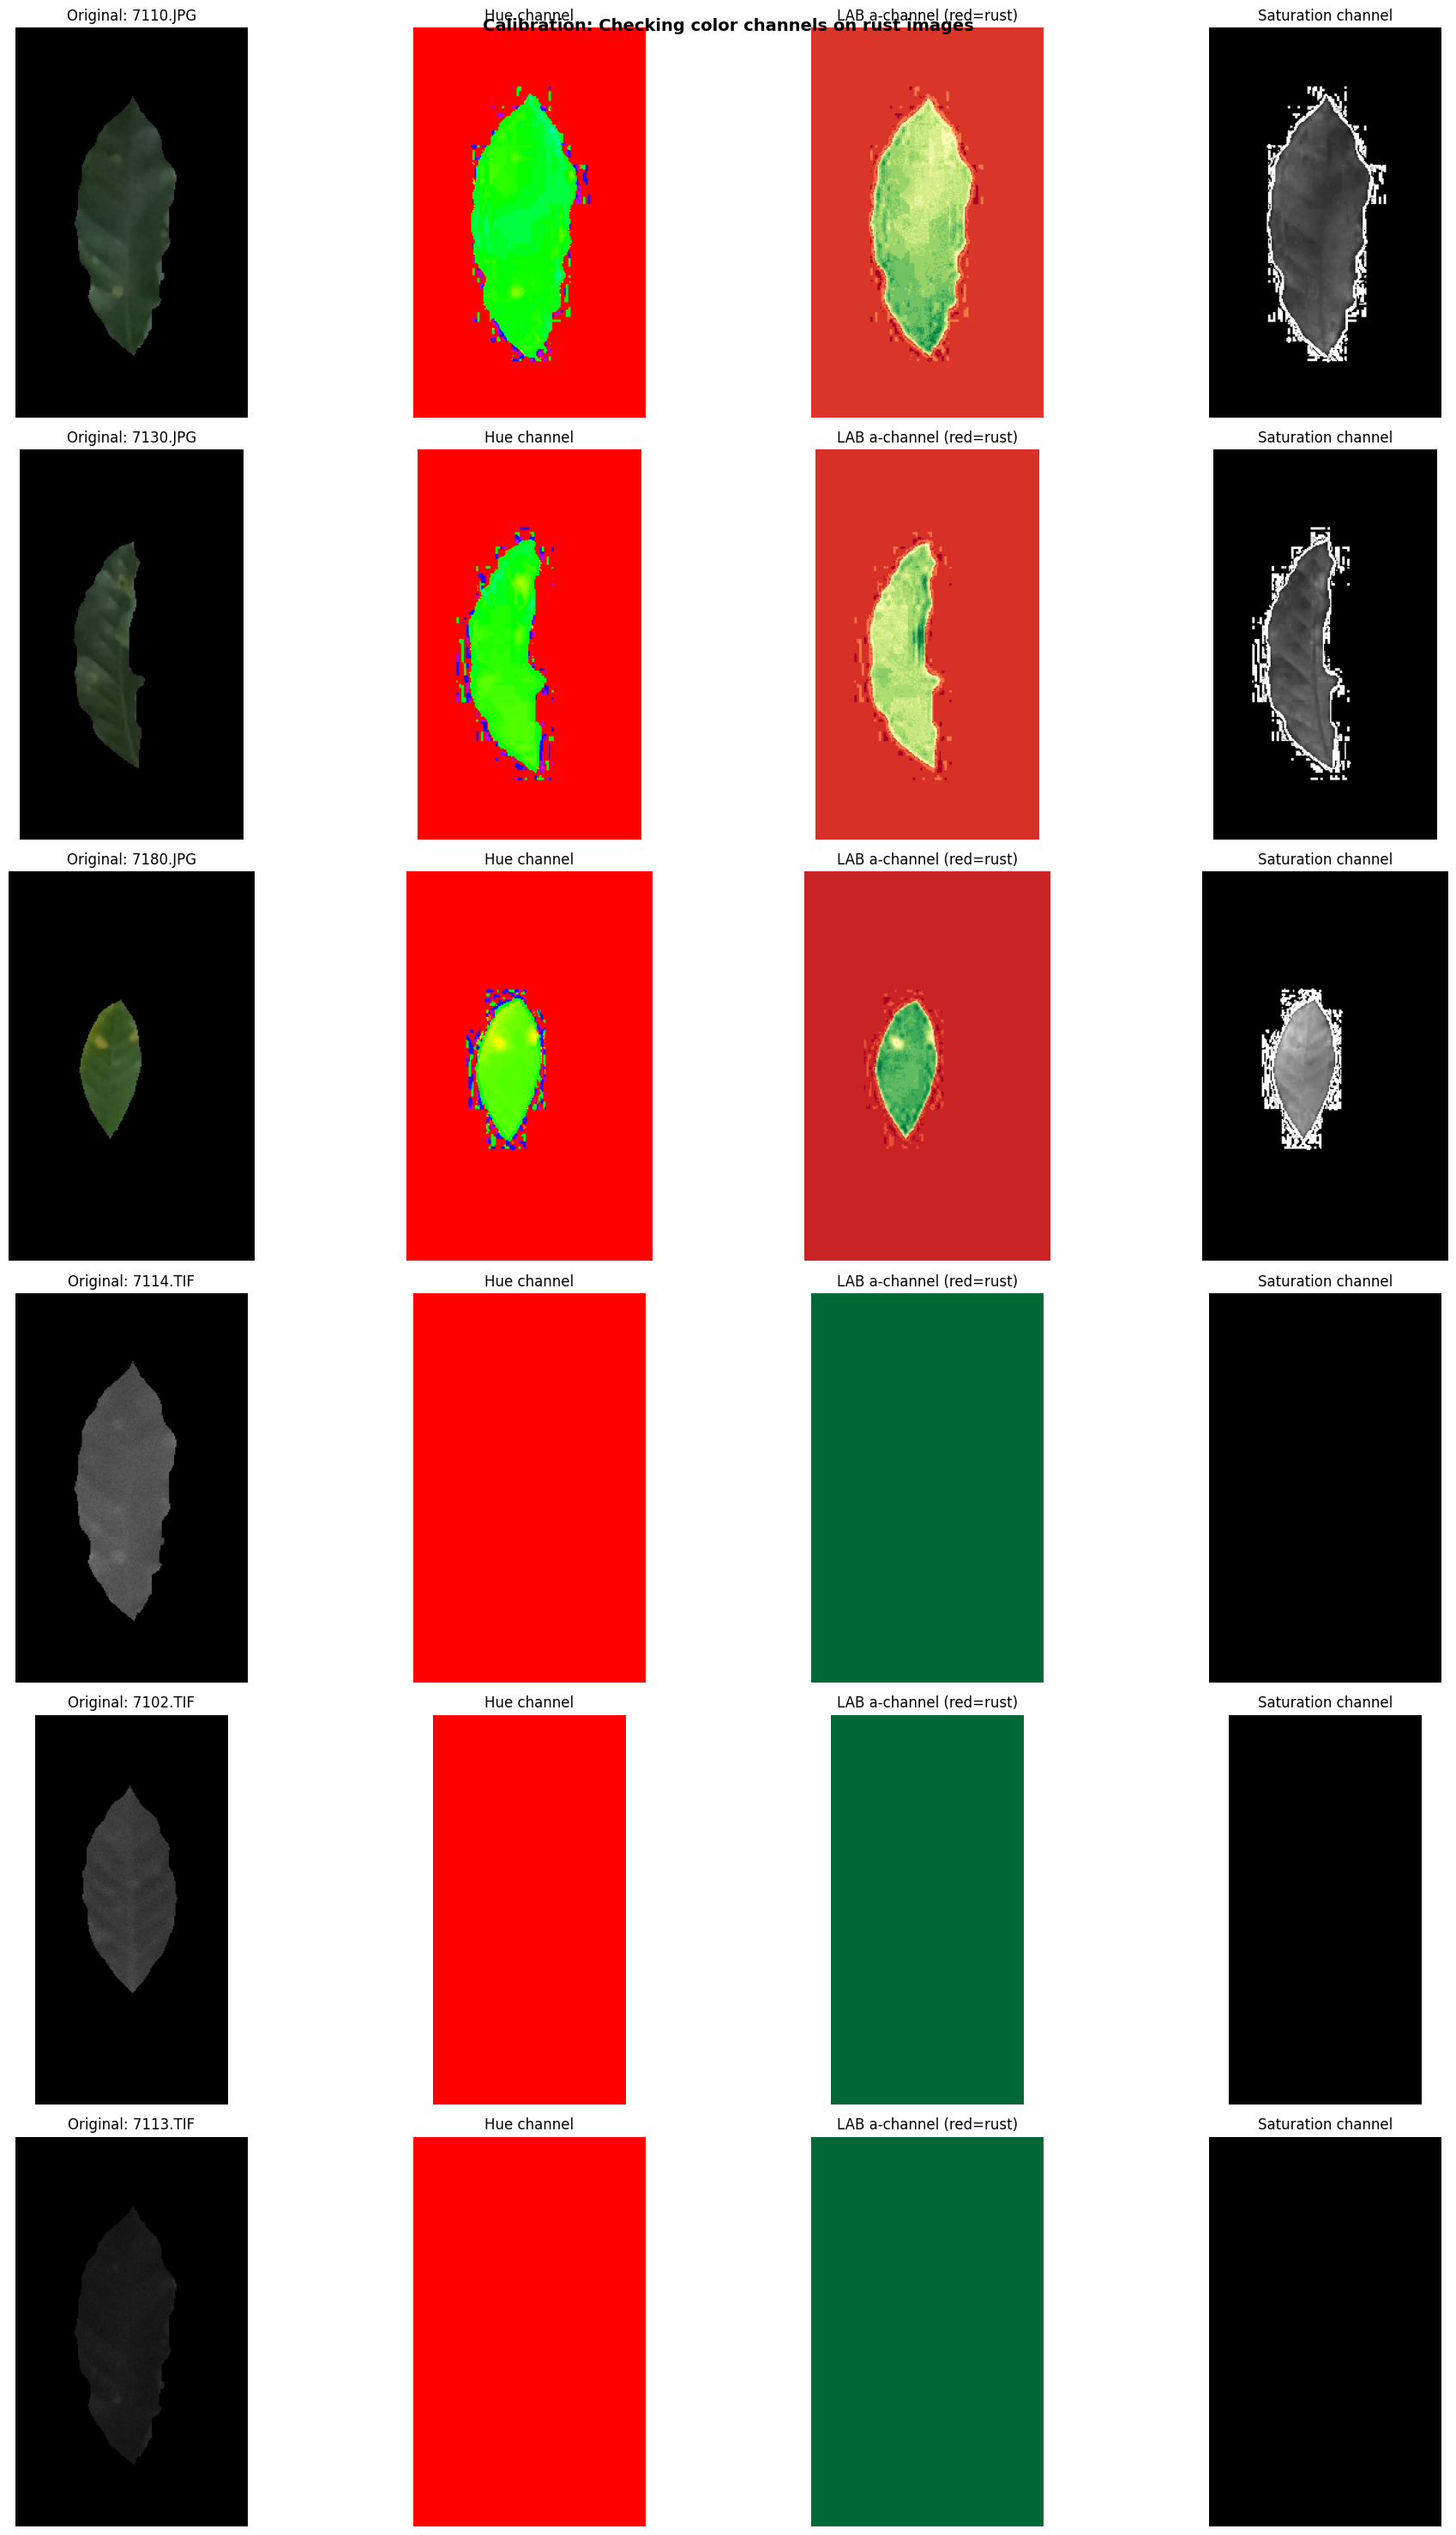

Use these channels to verify rust areas are visible in the Hue and LAB-a channels.


In [ ]:
# Pick a sample rust image to calibrate on
sample_images = list(Path(RUST_IMAGES_PATH).glob('*.JPG'))[:3] + \
                list(Path(RUST_IMAGES_PATH).glob('*.TIF'))[:3]

fig, axes = plt.subplots(len(sample_images), 4, figsize=(20, 5 * len(sample_images)))
fig.suptitle('Calibration: Checking color channels on rust images', fontsize=14, fontweight='bold')

for i, img_path in enumerate(sample_images):
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv     = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'Original: {img_path.name[:20]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hsv[:, :, 0], cmap='hsv')
    axes[i, 1].set_title('Hue channel')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(a, cmap='RdYlGn_r')
    axes[i, 2].set_title('LAB a-channel (red=rust)')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(hsv[:, :, 1], cmap='gray')
    axes[i, 3].set_title('Saturation channel')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()
print('Use these channels to verify rust areas are visible in the Hue and LAB-a channels.')

## Step 5: Segmentation Function (Tuned for Leaf Rust)

In [ ]:
def segment_rust(image_path):
    """
    Segment rust spots on leaves using multi-channel color analysis.
    Rust on leaves appears as brown/orange/yellow spots on a green background.
    Strategy:
      1. Isolate the leaf (remove background) using green channel dominance.
      2. Within the leaf, detect rust-colored pixels using HSV + LAB.
      3. Clean up with morphological operations.
    """
    img     = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv     = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # ── Step A: Isolate the leaf (green/yellow-green areas) ──────────────────
    # Leaves are green or yellowish-green in HSV
    lower_leaf = np.array([20,  20,  20])
    upper_leaf = np.array([100, 255, 255])
    leaf_mask  = cv2.inRange(hsv, lower_leaf, upper_leaf)

    # Also include brownish/rusted leaf tissue
    lower_leaf2 = np.array([0,  20, 20])
    upper_leaf2 = np.array([35, 255, 255])
    leaf_mask2  = cv2.inRange(hsv, lower_leaf2, upper_leaf2)
    leaf_mask   = cv2.bitwise_or(leaf_mask, leaf_mask2)

    # Fill holes in leaf mask
    kernel_large = np.ones((15, 15), np.uint8)
    leaf_mask    = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel_large)
    leaf_mask    = cv2.morphologyEx(leaf_mask, cv2.MORPH_DILATE, kernel_large)

    # ── Step B: Detect rust color within the leaf ────────────────────────────
    # Rust = orange/brown/yellow-brown spots
    # HSV range 1: orange-brown rust
    lower_rust1 = np.array([5,  50,  50])
    upper_rust1 = np.array([25, 255, 255])
    mask_rust1  = cv2.inRange(hsv, lower_rust1, upper_rust1)

    # HSV range 2: yellow-brown rust
    lower_rust2 = np.array([25, 40, 80])
    upper_rust2 = np.array([40, 200, 255])
    mask_rust2  = cv2.inRange(hsv, lower_rust2, upper_rust2)

    # LAB a-channel: rust has high red component (a > 128)
    _, mask_a = cv2.threshold(a, 128, 255, cv2.THRESH_BINARY)

    # LAB b-channel: rust has high yellow component (b > 130)
    _, mask_b = cv2.threshold(b, 130, 255, cv2.THRESH_BINARY)

    # Combine rust color masks
    rust_color = cv2.bitwise_or(mask_rust1, mask_rust2)
    rust_color = cv2.bitwise_or(rust_color, cv2.bitwise_and(mask_a, mask_b))

    # ── Step C: Restrict rust to leaf area only ──────────────────────────────
    rust_mask = cv2.bitwise_and(rust_color, leaf_mask)

    # ── Step D: Exclude pure green (healthy leaf tissue) ────────────────────
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask  = cv2.inRange(hsv, lower_green, upper_green)
    rust_mask   = cv2.bitwise_and(rust_mask, cv2.bitwise_not(green_mask))

    # ── Step E: Morphological cleanup ───────────────────────────────────────
    kernel = np.ones((5, 5), np.uint8)
    rust_mask = cv2.morphologyEx(rust_mask, cv2.MORPH_CLOSE, kernel)
    rust_mask = cv2.morphologyEx(rust_mask, cv2.MORPH_OPEN,  kernel)

    # ── Step F: Create overlay ───────────────────────────────────────────────
    overlay          = img_rgb.copy()
    overlay[rust_mask > 0] = [255, 80, 0]  # Orange highlight
    result           = cv2.addWeighted(img_rgb, 0.55, overlay, 0.45, 0)

    return img_rgb, rust_mask, result

print('Segmentation function ready!')

Segmentation function ready!


## Step 6: Test on Multiple Sample Images

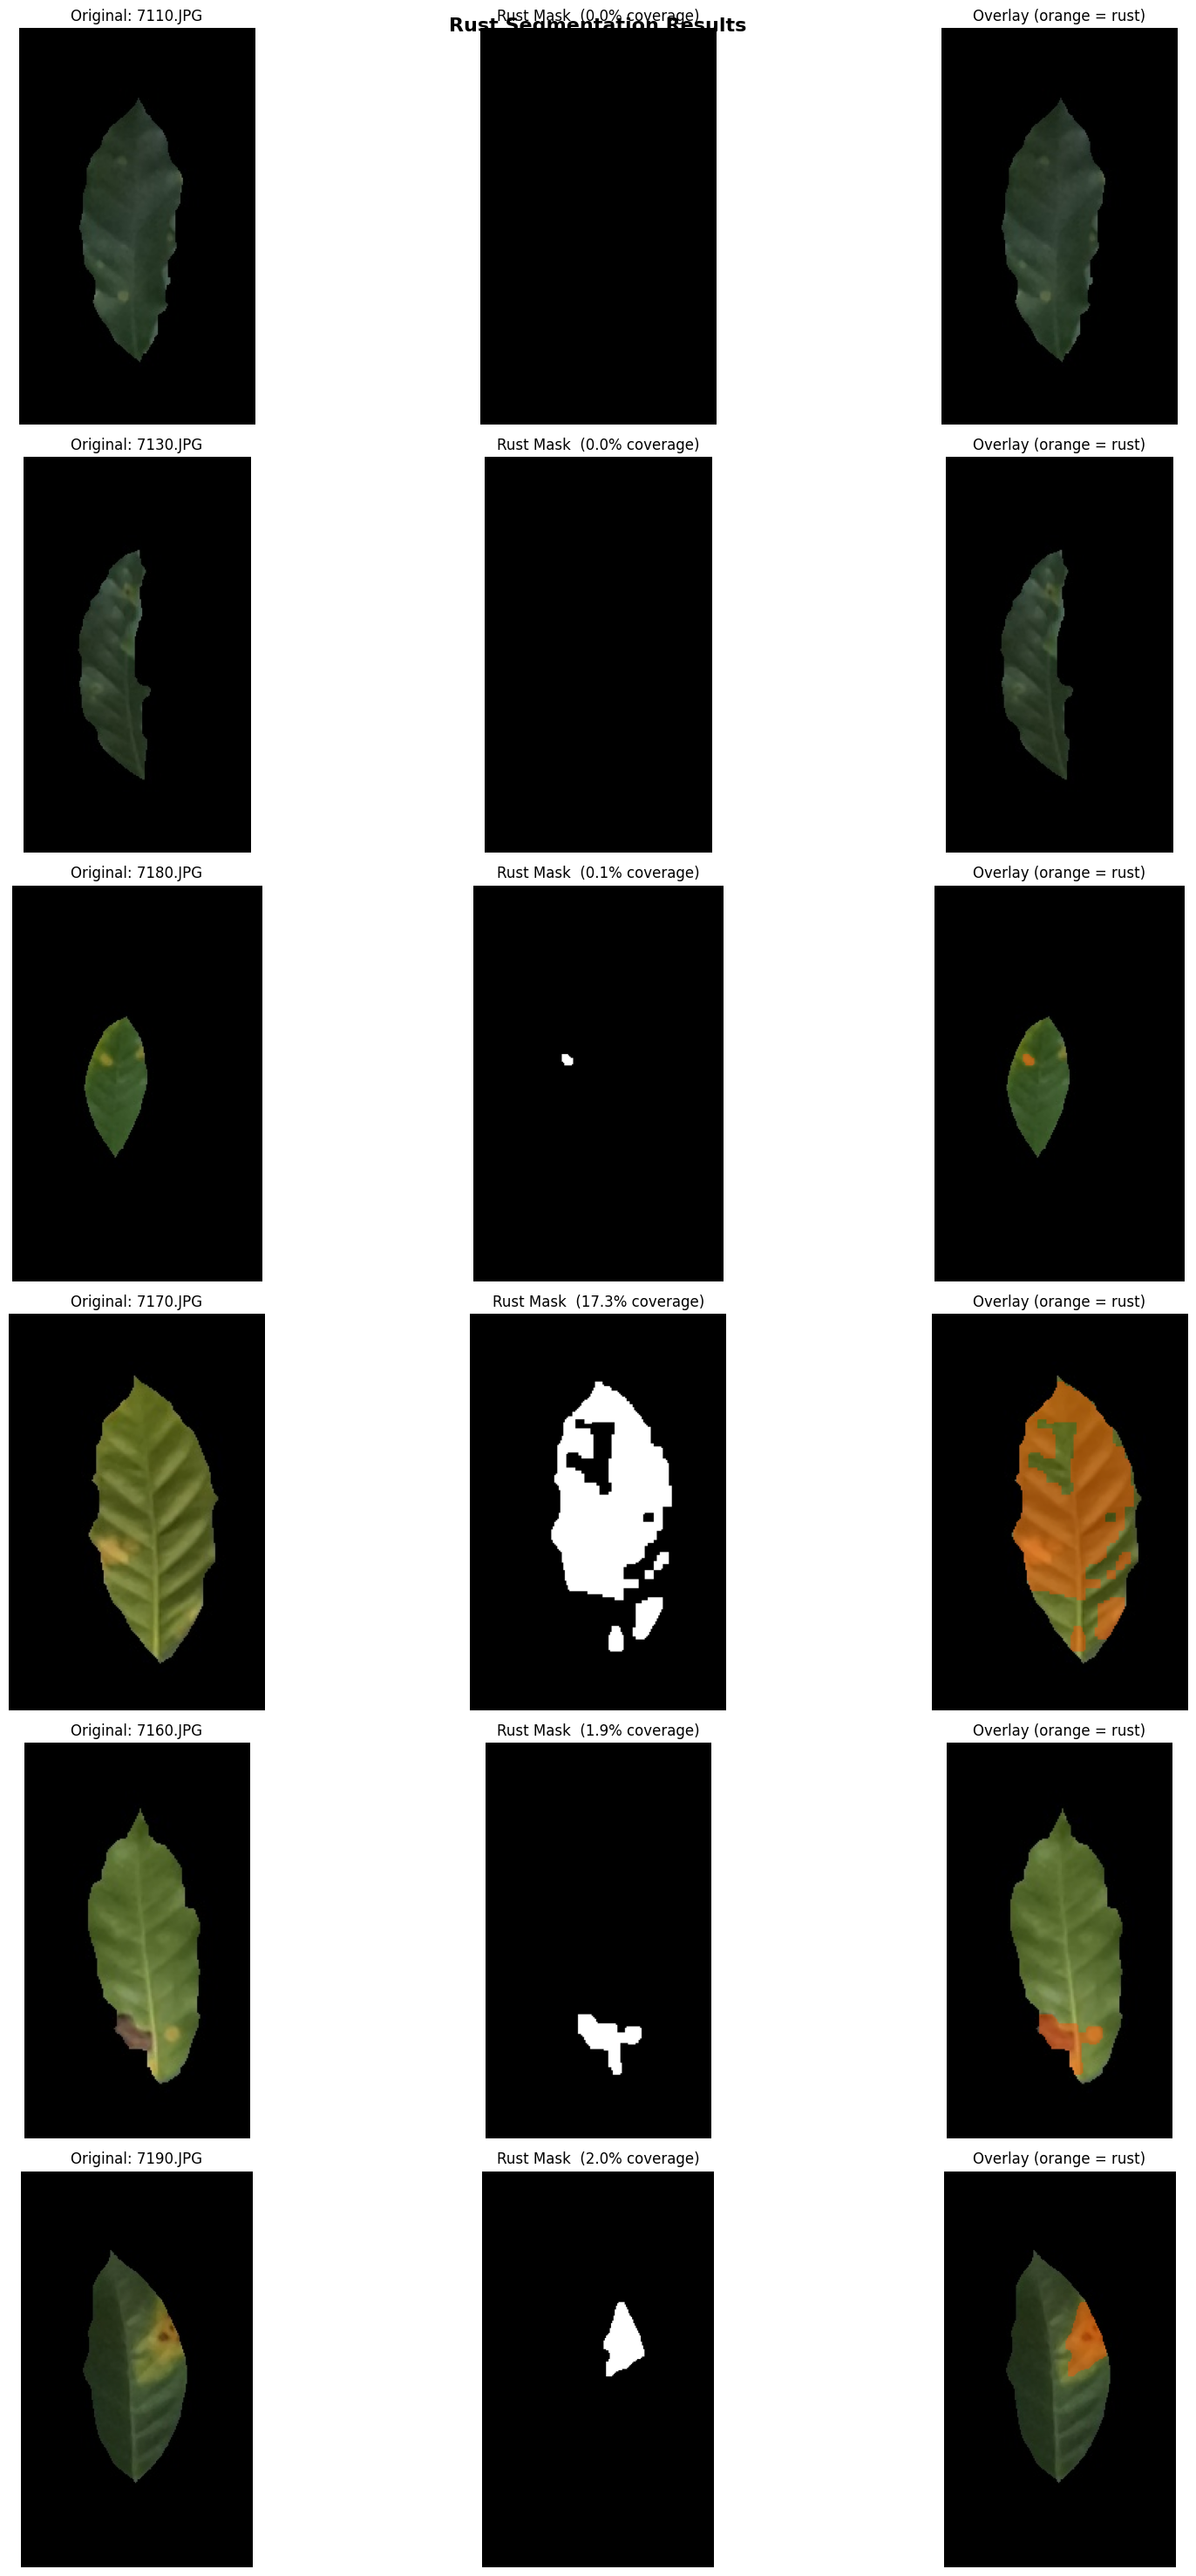

If segmentation looks wrong, adjust the HSV ranges in Step 5.


In [ ]:
sample_images = list(Path(RUST_IMAGES_PATH).glob('*.JPG'))[:6] + \
                list(Path(RUST_IMAGES_PATH).glob('*.TIF'))[:6]
sample_images = sample_images[:6]

fig, axes = plt.subplots(len(sample_images), 3, figsize=(18, 5 * len(sample_images)))
fig.suptitle('Rust Segmentation Results', fontsize=16, fontweight='bold')

for i, img_path in enumerate(sample_images):
    original, mask, overlay = segment_rust(img_path)
    rust_pct = (np.count_nonzero(mask) / mask.size) * 100

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f'Original: {img_path.name[:25]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'Rust Mask  ({rust_pct:.1f}% coverage)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay (orange = rust)')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/sample_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('If segmentation looks wrong, adjust the HSV ranges in Step 5.')

## Step 7: (Optional) Fine-tune HSV Ranges
### Only run this if Step 6 results look wrong

HSV channel statistics for: 7110.JPG
  Hue        min=0, max=173, mean=14.4
  Saturation min=0, max=255, mean=24.2
  Value      min=0, max=120, mean=12.2


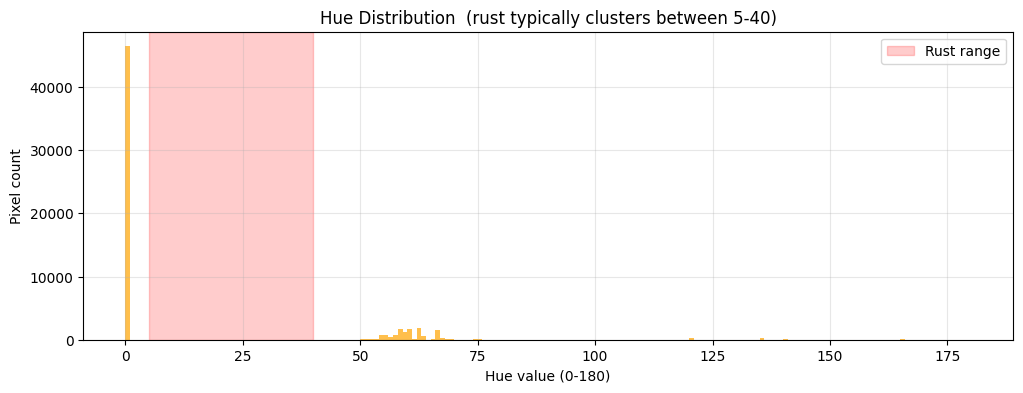

In [ ]:
# Pick one image and inspect its HSV values in the rust area
img_path = list(Path(RUST_IMAGES_PATH).glob('*.JPG'))[0]
img      = cv2.imread(str(img_path))
img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Print HSV stats for the whole image
print('HSV channel statistics for:', img_path.name)
print(f'  Hue        min={hsv[:,:,0].min()}, max={hsv[:,:,0].max()}, mean={hsv[:,:,0].mean():.1f}')
print(f'  Saturation min={hsv[:,:,1].min()}, max={hsv[:,:,1].max()}, mean={hsv[:,:,1].mean():.1f}')
print(f'  Value      min={hsv[:,:,2].min()}, max={hsv[:,:,2].max()}, mean={hsv[:,:,2].mean():.1f}')

# Show hue histogram to see where rust pixels cluster
plt.figure(figsize=(12, 4))
plt.hist(hsv[:,:,0].flatten(), bins=180, range=(0,180), color='orange', alpha=0.7)
plt.xlabel('Hue value (0-180)')
plt.ylabel('Pixel count')
plt.title('Hue Distribution  (rust typically clusters between 5-40)')
plt.axvspan(5, 40, alpha=0.2, color='red', label='Rust range')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 8: Label Creation Function

In [ ]:
def create_label(image_name, mask, image_shape, class_name):
    height, width = image_shape[:2]
    total_pixels  = mask.size
    rust_pixels   = int(np.count_nonzero(mask))
    rust_pct      = round((rust_pixels / total_pixels) * 100, 2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label = {
        'image_name':       image_name,
        'class':            class_name,
        'image_width':      int(width),
        'image_height':     int(height),
        'total_pixels':     int(total_pixels),
        'rust_pixels':      rust_pixels,
        'healthy_pixels':   int(total_pixels - rust_pixels),
        'rust_percentage':  rust_pct,
        'num_rust_regions': len(contours),
        'regions': []
    }

    for idx, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if area > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            label['regions'].append({
                'region_id':  idx,
                'area_pixels': int(area),
                'bbox': {'x': int(x), 'y': int(y), 'width': int(w), 'height': int(h)}
            })

    return label

print('Label function ready!')

Label function ready!


## Step 9: Process All Rust Images

In [ ]:
rust_images = list(Path(RUST_IMAGES_PATH).glob('*.JPG')) + \
              list(Path(RUST_IMAGES_PATH).glob('*.TIF'))

print(f'Processing {len(rust_images)} rust images...')

label_summary = []
processed = 0
errors    = 0

for img_path in tqdm(rust_images, desc='Segmenting rust images'):
    try:
        img                      = cv2.imread(str(img_path))
        original, mask, overlay  = segment_rust(img_path)
        stem                     = img_path.stem

        cv2.imwrite(f'{OUTPUT_PATH}/images/{stem}.png', img)
        cv2.imwrite(f'{OUTPUT_PATH}/masks/{stem}_mask.png', mask)
        cv2.imwrite(f'{OUTPUT_PATH}/visualization/{stem}_overlay.png',
                    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        label = create_label(img_path.name, mask, img.shape, 'rust')
        with open(f'{OUTPUT_PATH}/labels/{stem}.json', 'w') as f:
            json.dump(label, f, indent=2)

        label_summary.append(label)
        processed += 1

    except Exception as e:
        errors += 1
        print(f'Error: {img_path.name}: {e}')

print(f'Done: {processed} processed, {errors} errors')

Processing 5088 rust images...


Segmenting rust images:  16%|█▌        | 803/5088 [23:09<2:07:44,  1.79s/it]

Error: 2360.JPG: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'



Segmenting rust images:  72%|███████▏  | 3667/5088 [1:30:03<31:54,  1.35s/it]

## Step 10: Process All No-Rust Images

In [ ]:
norust_images = list(Path(NORUST_IMAGES_PATH).glob('*.JPG')) + \
                list(Path(NORUST_IMAGES_PATH).glob('*.TIF'))

print(f'Processing {len(norust_images)} no-rust images...')

for img_path in tqdm(norust_images, desc='No-rust images'):
    try:
        img  = cv2.imread(str(img_path))
        stem = img_path.stem

        cv2.imwrite(f'{OUTPUT_PATH}/images/{stem}.png', img)

        empty_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        cv2.imwrite(f'{OUTPUT_PATH}/masks/{stem}_mask.png', empty_mask)

        label = {
            'image_name':       img_path.name,
            'class':            'no_rust',
            'image_width':      int(img.shape[1]),
            'image_height':     int(img.shape[0]),
            'total_pixels':     int(img.shape[0] * img.shape[1]),
            'rust_pixels':      0,
            'healthy_pixels':   int(img.shape[0] * img.shape[1]),
            'rust_percentage':  0.0,
            'num_rust_regions': 0,
            'regions':          []
        }
        with open(f'{OUTPUT_PATH}/labels/{stem}.json', 'w') as f:
            json.dump(label, f, indent=2)

        label_summary.append(label)

    except Exception as e:
        print(f'Error: {img_path.name}: {e}')

print('Done!')

## Step 11: Create Master Label Files

In [ ]:
rows = [{
    'image_name':      l['image_name'],
    'class':           l['class'],
    'width':           l['image_width'],
    'height':          l['image_height'],
    'total_pixels':    l['total_pixels'],
    'rust_pixels':     l['rust_pixels'],
    'rust_percentage': l['rust_percentage'],
    'num_regions':     l['num_rust_regions']
} for l in label_summary]

df = pd.DataFrame(rows)
df.to_csv(f'{OUTPUT_PATH}/labels_summary.csv', index=False)

with open(f'{OUTPUT_PATH}/labels_index.json', 'w') as f:
    json.dump(label_summary, f, indent=2)

print(f'Total labeled: {len(df)}')
print(df.head(10).to_string())

## Step 12: Rust Coverage Distribution

In [ ]:
rust_df   = df[df['class'] == 'rust']
norust_df = df[df['class'] == 'no_rust']

print('=' * 60)
print('SEGMENTATION STATISTICS')
print('=' * 60)
print(f'Total images:  {len(df)}')
print(f'  Rust:        {len(rust_df)}')
print(f'  No-rust:     {len(norust_df)}')

if len(rust_df) > 0:
    print(f'\nRust Coverage:')
    print(f'  Average:  {rust_df["rust_percentage"].mean():.2f}%')
    print(f'  Median:   {rust_df["rust_percentage"].median():.2f}%')
    print(f'  Min:      {rust_df["rust_percentage"].min():.2f}%')
    print(f'  Max:      {rust_df["rust_percentage"].max():.2f}%')

    # Distribution plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].hist(rust_df['rust_percentage'], bins=50, color='brown', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Rust Coverage (%)')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_title('Rust Coverage Distribution')
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot(rust_df['rust_percentage'], vert=True)
    axes[1].set_ylabel('Rust Coverage (%)')
    axes[1].set_title('Rust Coverage Box Plot')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/rust_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()